In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import sys
from pyspark.sql import SparkSession

In [2]:
#parameter for master can be changed depending on the environment
spark = SparkSession.builder \
.master("local") \
.appName("accidents") \
.getOrCreate()

In [3]:
df = spark.read.csv("shared/US_Accidents_March23.csv", header=True, inferSchema=True)
#df.show(vertical=True)
df.printSchema()
# US_Accidents_March23
from pyspark.sql.functions import count
from pyspark.sql import functions as F
#Bool counts
bc_junction = df.groupBy("Junction").agg(count("*").alias("count"))
bc_junction.show()

bc_amenity = df.groupBy("Amenity").agg(count("*").alias("count"))
bc_amenity.show()
bc_crossing = df.groupBy("Crossing").agg(count("*").alias("count"))
bc_crossing.show()
bc_bump = df.groupBy("Bump").agg(count("*").alias("count"))
bc_bump.show()
bc_roundabout = df.groupBy("Roundabout").agg(count("*").alias("count"))
bc_roundabout.show()
bc_stop = df.groupBy("Stop").agg(count("*").alias("count"))
bc_stop.show()
#df.select(F.col("Junction"))
#df.select("Junction").count()
#df.selectExpr("Junction as newColumn").show()

root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- End_Lat: double (nullable = true)
 |-- End_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: timestamp (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Wind_Chill(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): double (nullable = true)
 |-- V

+--------+-------+--------+----+----------+------+
|Junction|Amenity|Crossing|Bump|Roundabout|  Stop|
+--------+-------+--------+----+----------+------+
|  571342|  96334|  873763|3514|       249|214371|
+--------+-------+--------+----+----------+------+



<Figure size 900x900 with 0 Axes>

([<matplotlib.patches.Wedge at 0x7f0a444859d0>,
 [Text(0.5756176450092002, 0.9373709653888702, 'Junction'),
  Text(-0.6581340034380646, 0.881396411110566, 'Amenity'),
  Text(-0.7643031211316437, -0.7911009663933095, 'Crossing'),
  Text(0.7876685515097732, -0.7678399917707439, 'Bump'),
  Text(0.7928095217967243, -0.7625306958729264, 'Roundabout'),
  Text(1.020407585145993, -0.4108142648162589, 'Stop')],
 [Text(0.3139732609141092, 0.5112932538484746, '32.5%'),
  Text(-0.3589821836934897, 0.4807616787875814, '5.5%'),
  Text(-0.4168926115263511, -0.4315096180327142, '49.7%'),
  Text(0.4296373917326035, -0.418821813693133, '0.2%'),
  Text(0.43244155734366774, -0.41592583411250533, '0.0%'),
  Text(0.5565859555341779, -0.22408050808159571, '12.2%')])

Text(0.5, 1.0, 'Proportion of True Values Across Features')

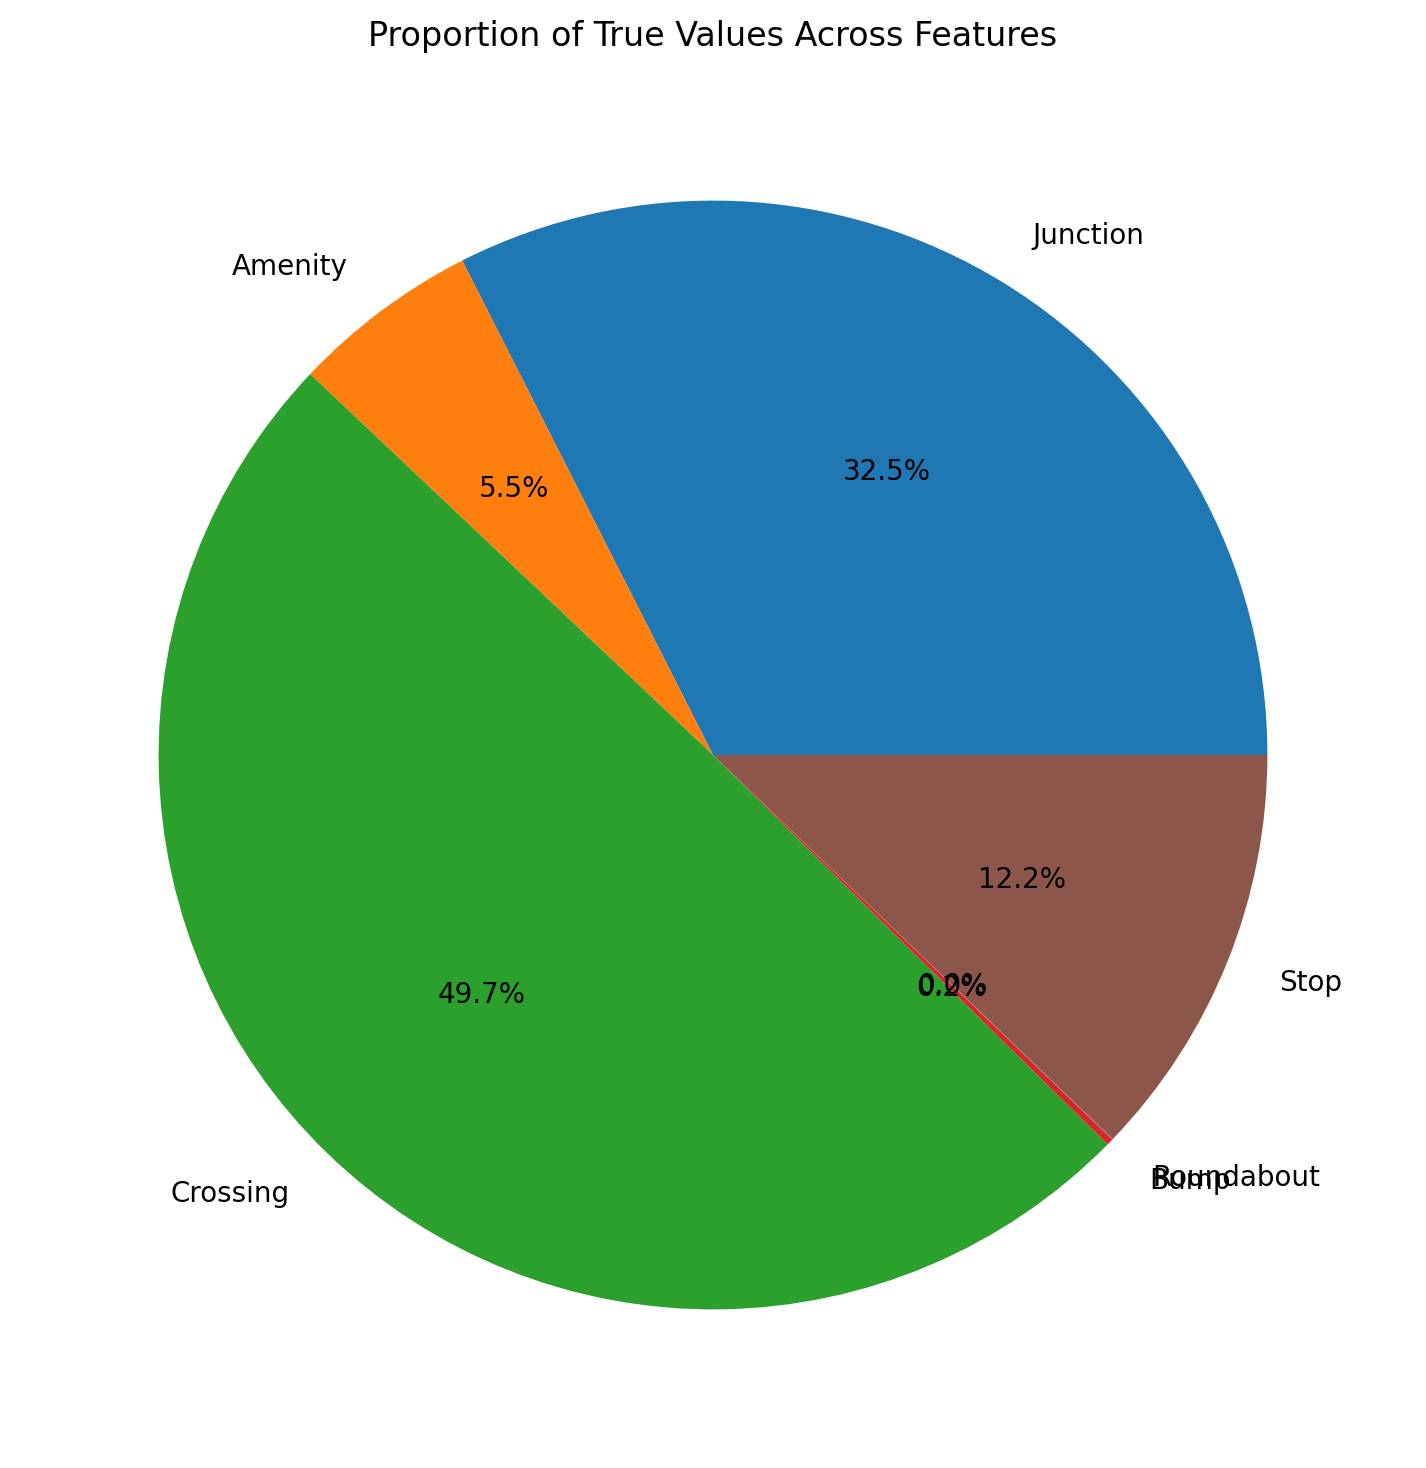

In [4]:
total = df.count()
from pyspark.sql.functions import sum, col

true_counts = df.select(
    sum(col("Junction").cast("int")).alias("Junction"),
    sum(col("Amenity").cast("int")).alias("Amenity"),
    sum(col("Crossing").cast("int")).alias("Crossing"),
    sum(col("Bump").cast("int")).alias("Bump"),
    sum(col("Roundabout").cast("int")).alias("Roundabout"),
    sum(col("Stop").cast("int")).alias("Stop")
)

true_counts.show()

pdf = true_counts.toPandas().T.reset_index()
pdf.columns = ["Feature", "TrueCount"]

pdf["Percentage"] = pdf["TrueCount"] / total

import matplotlib.pyplot as plt

plt.figure(figsize=(9,9))
plt.pie(pdf["TrueCount"], labels=pdf["Feature"], autopct='%1.1f%%')
plt.title("Proportion of True Values Across Features")
plt.show()

<Axes: >

Text(0, 0.5, 'Proportion True')

Text(0.5, 1.0, 'True Rate per Feature')

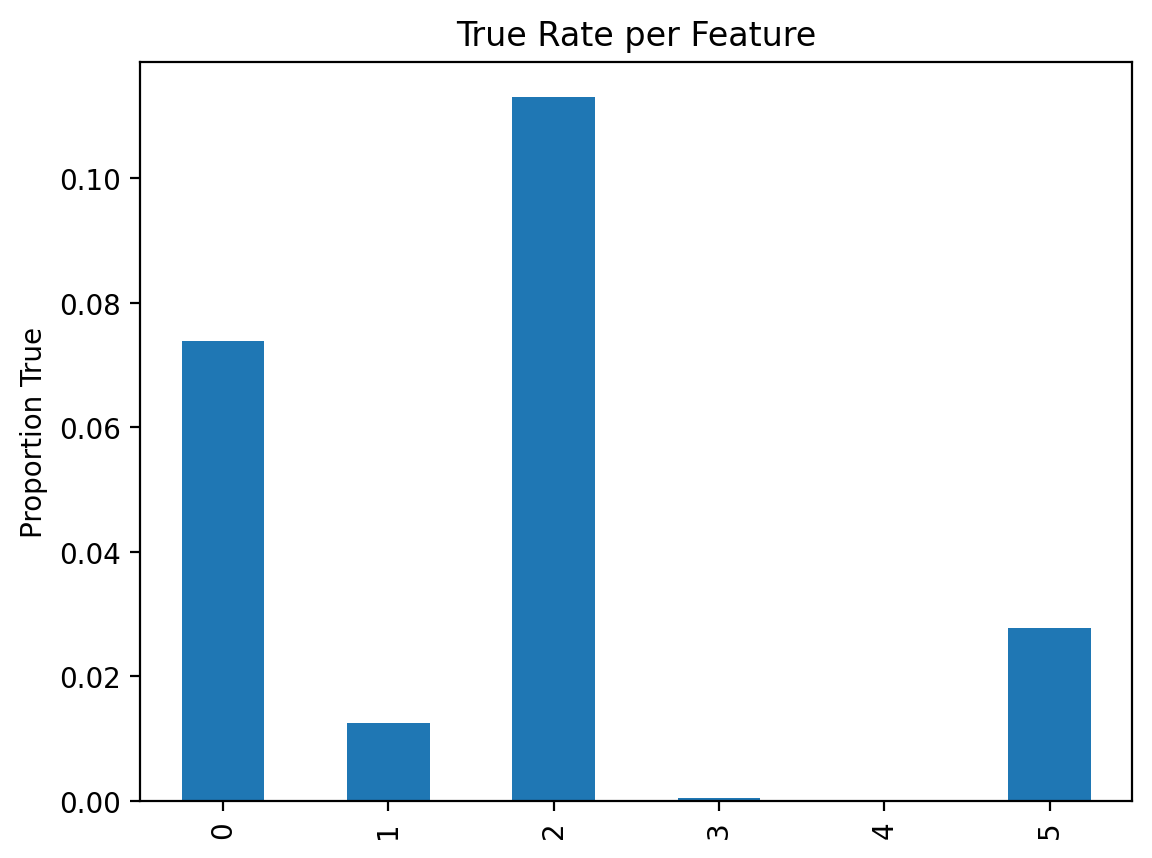

In [5]:
pdf["Percentage"].plot(kind="bar")
plt.ylabel("Proportion True")
plt.title("True Rate per Feature")
plt.show()

In [6]:
from pyspark.sql.functions import sum, col

total = df.count()

true_counts = df.select(
    sum(col("Junction").cast("int")).alias("Junction"),
    sum(col("Amenity").cast("int")).alias("Amenity"),
    sum(col("Crossing").cast("int")).alias("Crossing"),
    sum(col("Bump").cast("int")).alias("Bump"),
    sum(col("Roundabout").cast("int")).alias("Roundabout"),
    sum(col("Stop").cast("int")).alias("Stop")
)

pdf = true_counts.toPandas().T.reset_index()
pdf.columns = ["Feature", "TrueCount"]
pdf["Percentage"] = pdf["TrueCount"] / total

<Figure size 800x500 with 0 Axes>

Text(0, 1, 'Junction')

Text(1, 1, 'Amenity')

Text(2, 1, 'Crossing')

Text(3, 1, 'Bump')

Text(4, 1, 'Roundabout')

Text(5, 1, 'Stop')

([], [])

([], [])

Text(0.5, 1.0, 'Feature Presence (Bubble Size = % of True)')

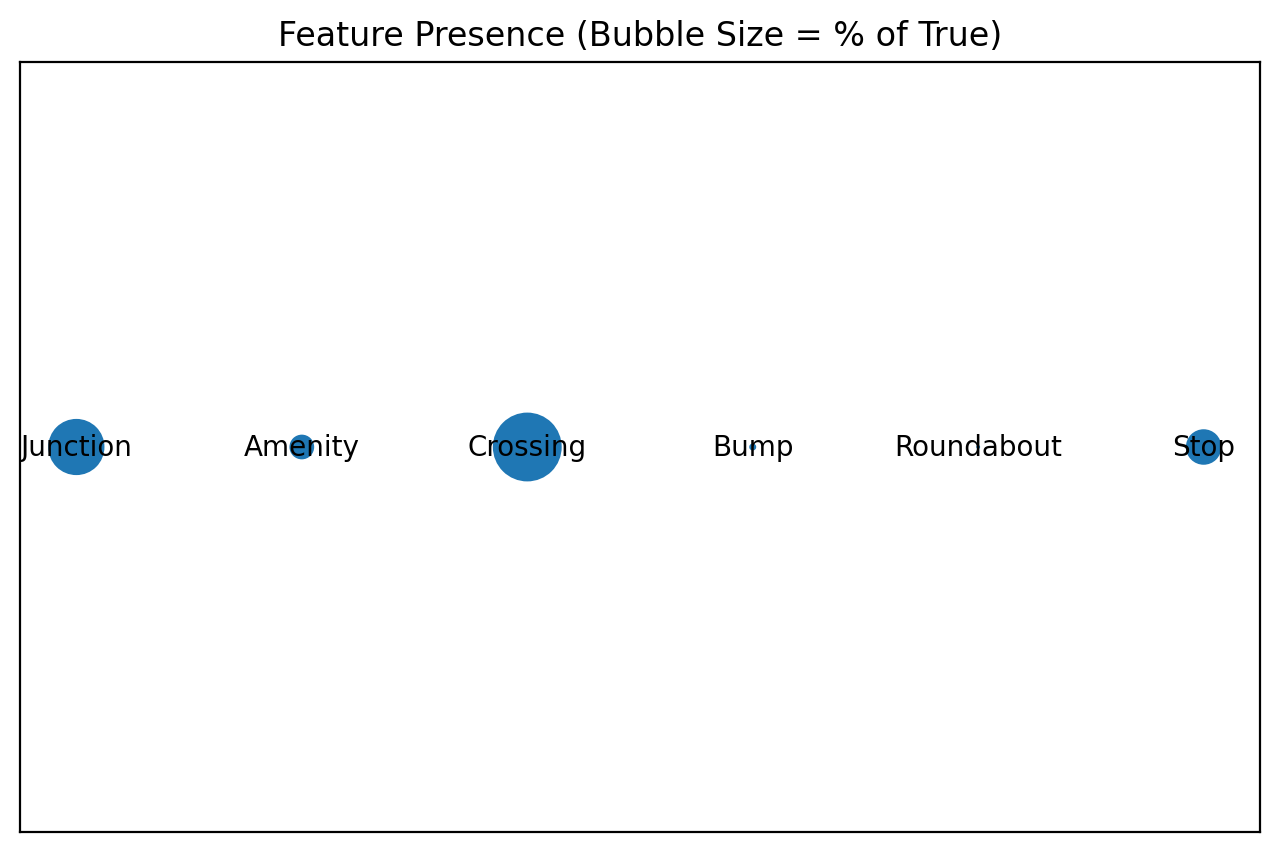

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# x positions (just spread them out)
x = range(len(pdf))

# bubble sizes (scale up for visibility)
sizes = pdf["Percentage"] * 5000

plt.scatter(x, [1]*len(pdf), s=sizes)

# labels
for i, txt in enumerate(pdf["Feature"]):
    plt.text(i, 1, txt, ha='center', va='center')

plt.xticks([])
plt.yticks([])
plt.title("Feature Presence (Bubble Size = % of True)")
plt.show()